In [1]:
import sys
from pathlib import Path

Duong_Dan_Goc = Path(r"D:\HR Analytics")

sys.path.append(
    str(Duong_Dan_Goc / "python" / "src")
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.base import clone

In [2]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,TargetNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [5]:
featurea_So= [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]
features_Nhi_Phan = [
    "LamThemGio",
    "DuocThangChucNamTruoc"
]
features_danh_muc = [
    "PhongBan",
    "ChucDanh"
]
target = "TargetNghiViec"
feature_cot =( featurea_So + features_Nhi_Phan + features_danh_muc)


In [4]:
#Chia bộ dữ liệu train/valid/test
#Train: < 2023 | valid: 2024 | test: 2025

train = df[df["Nam"]==2023].copy()

valid = df[df["Nam"]==2024].copy()
test = df[df["Nam"]==2025].copy()

print("\ntrain")
print(train["Nam"].value_counts().sort_index())
print("\nvalid")
print(valid["Nam"].value_counts().sort_index())
print("\ntest")
print(test["Nam"].value_counts().sort_index())


train
Nam
2023    5195
Name: count, dtype: int64

valid
Nam
2024    5244
Name: count, dtype: int64

test
Nam
2025    4431
Name: count, dtype: int64


In [6]:
x_train = train[feature_cot].copy()
y_train = train[target].copy()

x_valid = valid[feature_cot].copy()
y_valid = valid[target].copy()

x_test = test[feature_cot].copy()
y_test = test[target].copy()

In [7]:
tree_tien_xu_ly = ColumnTransformer(
    transformers=[
        (
            "so",
            "passthrough",
            featurea_So
        ),

        (
            "nhi_phan",
            "passthrough",
            features_Nhi_Phan
        ),

        (
            "phan_loai",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_danh_muc
        )
    ]
)

In [8]:
X_train_tree = (
    tree_tien_xu_ly.fit_transform(
        x_train
    )
)

X_valid_tree = (
    tree_tien_xu_ly.transform(
        x_valid
    )
)

X_test_tree = (
    tree_tien_xu_ly.transform(
        x_test
    )
)

In [9]:
dt_baseline = DecisionTreeClassifier(
    random_state=42
)

dt_baseline.fit(
    X_train_tree,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [10]:
pred_dt_baseline = (
    dt_baseline.predict(
        X_valid_tree
    )
)

proba_dt_baseline = (
    dt_baseline.predict_proba(
        X_valid_tree
    )[:, 1]
)

In [11]:
print(
    classification_report(
        y_valid,
        pred_dt_baseline,
        digits=4
    )
)
print(
    confusion_matrix(
        y_valid,
        pred_dt_baseline
    )
)

              precision    recall  f1-score   support

           0     0.8577    0.8515    0.8546      4431
           1     0.2213    0.2300    0.2256       813

    accuracy                         0.7551      5244
   macro avg     0.5395    0.5408    0.5401      5244
weighted avg     0.7590    0.7551    0.7571      5244

[[3773  658]
 [ 626  187]]


In [12]:
dt_max_depth = [
    3,
    5,
    7,
    10,
    15,
    None
]

dt_min_leaf = [
    5,
    10,
    20,
    30
]

dt_min_split = [
    2,
    10,
    20
]

dt_class_weight = [
    None,
    "balanced"
]

In [13]:
ket_qua_dt = []

for depth in dt_max_depth:

    for leaf in dt_min_leaf:

        for split in dt_min_split:

            for cw in dt_class_weight:

                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    class_weight=cw,
                    random_state=42
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                pred = (
                    proba >= 0.5
                ).astype(int)

                ket_qua_dt.append({
                    "MaxDepth": depth,
                    "MinLeaf": leaf,
                    "MinSplit": split,
                    "ClassWeight": str(cw),

                    "Accuracy":
                        accuracy_score(
                            y_valid,
                            pred
                        ),

                    "Precision":
                        precision_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "Recall":
                        recall_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "F1":
                        f1_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            proba
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            proba
                        )
                })

In [14]:
ket_qua_dt = pd.DataFrame(
    ket_qua_dt
)
ket_qua_dt.sort_values(
    [
        "F1",
        "Recall"
    ],
    ascending=False
).head(20)

,MaxDepth,MinLeaf,MinSplit,ClassWeight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
19,3.0,30,2,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
21,3.0,30,10,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
23,3.0,30,20,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
37,5.0,20,2,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
39,5.0,20,10,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
41,5.0,20,20,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
31,5.0,10,2,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
33,5.0,10,10,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
35,5.0,10,20,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
1,3.0,5,2,balanced,0.729977,0.285714,0.494465,0.362162,0.677079,0.261104


In [15]:
threshold_values = np.arange(
    0.10,
    0.71,
    0.02
)
ket_qua_dt_threshold = []

for depth in dt_max_depth:

    for leaf in dt_min_leaf:

        for split in dt_min_split:

            for cw in dt_class_weight:

                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    class_weight=cw,
                    random_state=42
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                roc = roc_auc_score(
                    y_valid,
                    proba
                )

                pr = average_precision_score(
                    y_valid,
                    proba
                )

                for threshold in threshold_values:

                    pred = (
                        proba >= threshold
                    ).astype(int)

                    ket_qua_dt_threshold.append({
                        "MaxDepth": depth,
                        "MinLeaf": leaf,
                        "MinSplit": split,
                        "ClassWeight": str(cw),

                        "Threshold":
                            round(
                                threshold,
                                2
                            ),

                        "Accuracy":
                            accuracy_score(
                                y_valid,
                                pred
                            ),

                        "Precision":
                            precision_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "Recall":
                            recall_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "F1":
                            f1_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "ROC_AUC": roc,
                        "PR_AUC": pr
                    })

In [16]:
ket_qua_dt_threshold = pd.DataFrame(
    ket_qua_dt_threshold
)

In [17]:
(
    ket_qua_dt_threshold[
        ket_qua_dt_threshold[
            "Recall"
        ] >= 0.50
    ]
    .sort_values(
        [
            "F1",
            "Precision"
        ],
        ascending=False
    )
    .head(20)
)

,MaxDepth,MinLeaf,MinSplit,ClassWeight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
748,5.0,5,2,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
810,5.0,5,10,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
872,5.0,5,20,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
561,3.0,30,2,None,0.16,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
562,3.0,30,2,None,0.18,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
563,3.0,30,2,None,0.20,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
608,3.0,30,2,balanced,0.48,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
609,3.0,30,2,balanced,0.50,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
610,3.0,30,2,balanced,0.52,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
611,3.0,30,2,balanced,0.54,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478


In [18]:
best_dt_row = (
    ket_qua_dt_threshold
    .sort_values(
        [
            "F1",
            "Recall"
        ],
        ascending=False
    )
    .iloc[0]
)

best_dt_row

MaxDepth            5.0
MinLeaf               5
MinSplit              2
ClassWeight        None
Threshold          0.18
Accuracy       0.693555
Precision      0.268917
Recall         0.568266
F1             0.365073
ROC_AUC        0.678763
PR_AUC         0.272976
Name: 748, dtype: object

In [20]:
BEST_DT_DEPTH = (
    None
    if pd.isna(
        best_dt_row["MaxDepth"]
    )
    else int(
        best_dt_row["MaxDepth"]
    )
)

BEST_DT_LEAF = int(
    best_dt_row["MinLeaf"]
)

BEST_DT_SPLIT = int(
    best_dt_row["MinSplit"]
)

BEST_DT_CW = (
    None
    if best_dt_row["ClassWeight"] == "None"
    else "balanced"
)

BEST_DT_THRESHOLD = float(
    best_dt_row["Threshold"]
)

print(
    "Depth:",
    BEST_DT_DEPTH
)

print(
    "Leaf:",
    BEST_DT_LEAF
)

print(
    "Split:",
    BEST_DT_SPLIT
)

print(
    "ClassWeight:",
    BEST_DT_CW
)

print(
    "Threshold:",
    BEST_DT_THRESHOLD
)

Depth: 5
Leaf: 5
Split: 2
ClassWeight: None
Threshold: 0.18


In [21]:
final_train = df[
    df["Nam"] == 2024
].copy()

final_test = df[
    df["Nam"] == 2025
].copy()

In [22]:
X_final_train = final_train[
    feature_cot
].copy()

y_final_train = final_train[
    target
].copy()

X_final_test = final_test[
    feature_cot
].copy()

y_final_test = final_test[
    target
].copy()

In [23]:
from sklearn.base import clone

final_tree_preprocessor = clone(
    tree_tien_xu_ly
)

X_final_train_tree = (
    final_tree_preprocessor.fit_transform(
        X_final_train
    )
)

X_final_test_tree = (
    final_tree_preprocessor.transform(
        X_final_test
    )
)

In [24]:
print(
    "Final Train:",
    X_final_train_tree.shape
)

print(
    "Final Test:",
    X_final_test_tree.shape
)

Final Train: (5244, 44)
Final Test: (4431, 44)


In [25]:
final_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
    class_weight=None,
    random_state=42
)

final_dt.fit(
    X_final_train_tree,
    y_final_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [26]:
proba_dt_test = (
    final_dt.predict_proba(
        X_final_test_tree
    )[:, 1]
)

pred_dt_test = (
    proba_dt_test >= 0.18
).astype(int)

In [27]:
print(
    classification_report(
        y_final_test,
        pred_dt_test,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9075    0.6929    0.7858      3767
           1     0.2559    0.5994    0.3587       664

    accuracy                         0.6789      4431
   macro avg     0.5817    0.6461    0.5723      4431
weighted avg     0.8099    0.6789    0.7218      4431



In [28]:
cm_dt = confusion_matrix(
    y_final_test,
    pred_dt_test
)

print(cm_dt)

[[2610 1157]
 [ 266  398]]


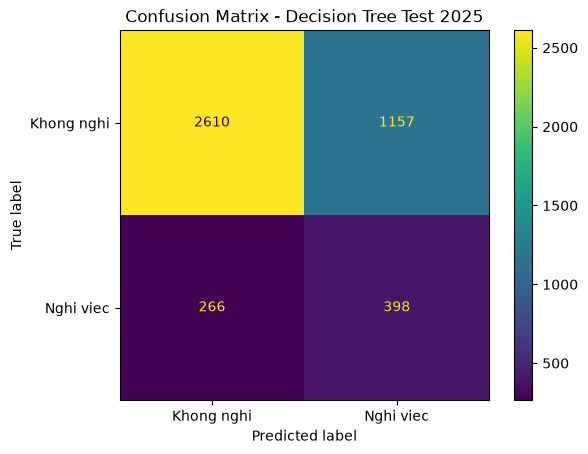

In [29]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=[
        "Khong nghi",
        "Nghi viec"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Decision Tree Test 2025"
)

plt.show()

In [30]:
ket_qua_dt_test = {
    "Accuracy": accuracy_score(
        y_final_test,
        pred_dt_test
    ),

    "Precision": precision_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "Recall": recall_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "F1": f1_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_final_test,
        proba_dt_test
    ),

    "PR_AUC": average_precision_score(
        y_final_test,
        proba_dt_test
    )
}

pd.Series(
    ket_qua_dt_test
).round(4)

Accuracy     0.6789
Precision    0.2559
Recall       0.5994
F1           0.3587
ROC_AUC      0.6757
PR_AUC       0.2583
dtype: float64

In [31]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train_tree,
    y_train
)

pred_rf_baseline = rf_baseline.predict(
    X_valid_tree
)

proba_rf_baseline = (
    rf_baseline.predict_proba(
        X_valid_tree
    )[:, 1]
)

print(
    classification_report(
        y_valid,
        pred_rf_baseline,
        digits=4
    )
)

print(
    confusion_matrix(
        y_valid,
        pred_rf_baseline
    )
)

              precision    recall  f1-score   support

           0     0.8472    0.9957    0.9154      4431
           1     0.4722    0.0209    0.0400       813

    accuracy                         0.8446      5244
   macro avg     0.6597    0.5083    0.4777      5244
weighted avg     0.7890    0.8446    0.7797      5244

[[4412   19]
 [ 796   17]]


In [32]:
rf_n_estimators = [
    100,
    200,
    300
]

rf_max_depth = [
    5,
    10,
    15,
    None
]

rf_min_leaf = [
    2,
    5,
    10
]

rf_class_weight = [
    None,
    "balanced",
    "balanced_subsample"
]

In [33]:
ket_qua_rf = []

for n_tree in rf_n_estimators:

    for depth in rf_max_depth:

        for leaf in rf_min_leaf:

            for cw in rf_class_weight:

                model = RandomForestClassifier(
                    n_estimators=n_tree,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    class_weight=cw,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                pred = (
                    proba >= 0.5
                ).astype(int)

                ket_qua_rf.append({
                    "NTrees": n_tree,
                    "MaxDepth": depth,
                    "MinLeaf": leaf,
                    "ClassWeight": str(cw),

                    "Accuracy":
                        accuracy_score(
                            y_valid,
                            pred
                        ),

                    "Precision":
                        precision_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "Recall":
                        recall_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "F1":
                        f1_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            proba
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            proba
                        )
                })

In [34]:
ket_qua_rf = pd.DataFrame(
    ket_qua_rf
)

ket_qua_rf.sort_values(
    ["F1", "Recall"],
    ascending=False
).head(20)

,NTrees,MaxDepth,MinLeaf,ClassWeight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
7,100,5.0,10,balanced,0.704615,0.283019,0.590406,0.382623,0.706033,0.317218
79,300,5.0,10,balanced,0.702708,0.281871,0.592866,0.382085,0.707208,0.320586
1,100,5.0,2,balanced,0.704996,0.282840,0.587946,0.381942,0.704807,0.315638
76,300,5.0,5,balanced,0.704615,0.282506,0.587946,0.381637,0.706418,0.316636
40,200,5.0,5,balanced,0.701564,0.280630,0.591636,0.380689,0.705708,0.315020
2,100,5.0,2,balanced_subsample,0.719298,0.289187,0.555966,0.380471,0.706215,0.316556
73,300,5.0,2,balanced,0.703661,0.281416,0.586716,0.380383,0.706140,0.321059
80,300,5.0,10,balanced_subsample,0.713387,0.285714,0.565806,0.379695,0.706048,0.314715
43,200,5.0,10,balanced,0.700229,0.279489,0.591636,0.379637,0.706647,0.317407
70,200,NaN,10,balanced,0.729405,0.294437,0.533825,0.379537,0.705947,0.314523
